# TT-25 - MLP voi Keras: Cham diem khach hang tiem nang mua bao hiem o to
Du lieu: Health Insurance Cross Sell Prediction, 381.109 dong x 12 cot, Response ~12.3%.


## 1. EDA

(381109, 11)
Ty le quan tam chung: 0.12256336113815208


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6648\930960354.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(nhom_tuoi)["Response"].mean().plot(kind="bar", ax=axes[2])


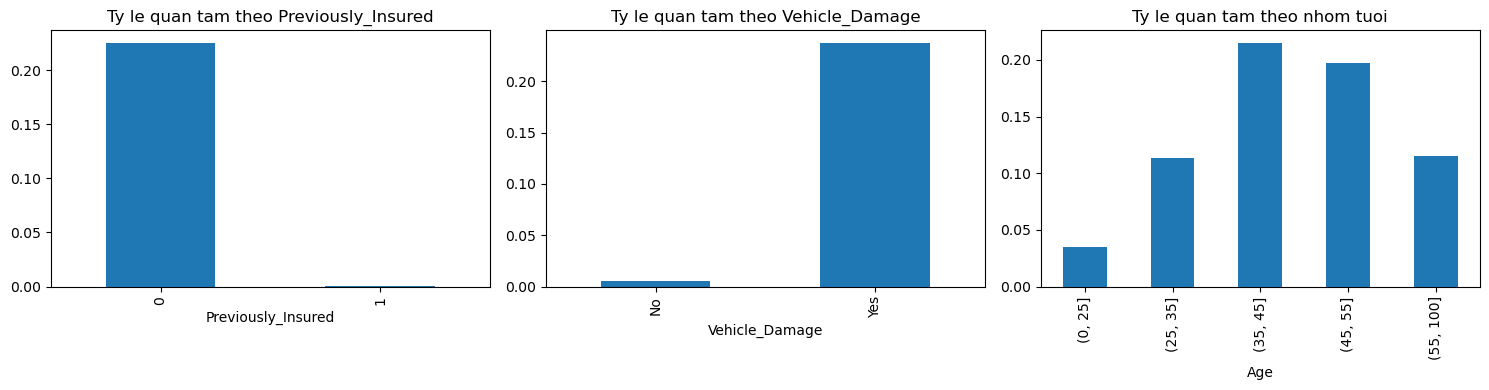

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("health_insurance.csv").drop(columns="id")
print(df.shape)
print("Ty le quan tam chung:", df["Response"].mean())

nhom_tuoi = pd.cut(df["Age"], bins=[0, 25, 35, 45, 55, 100])
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df.groupby("Previously_Insured")["Response"].mean().plot(kind="bar", ax=axes[0])
axes[0].set_title("Ty le quan tam theo Previously_Insured")
df.groupby("Vehicle_Damage")["Response"].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Ty le quan tam theo Vehicle_Damage")
df.groupby(nhom_tuoi)["Response"].mean().plot(kind="bar", ax=axes[2])
axes[2].set_title("Ty le quan tam theo nhom tuoi")
plt.tight_layout()
plt.show()
# Previously_Insured KHONG phai ro ri: thong tin nay biet TRUOC khi goi dien, duoc phep dung


## 2. Tien xu ly

In [2]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

df["Annual_Premium_log"] = np.log1p(df["Annual_Premium"])   # lech phai manh -> log1p truoc scale
df["Vehicle_Age"] = df["Vehicle_Age"].map({"< 1 Year": 0, "1-2 Year": 1, "> 2 Years": 2})
df = pd.get_dummies(df, columns=["Gender", "Vehicle_Damage"], drop_first=True)

# Region_Code va Policy_Sales_Channel: giu dang ma so nguyen de dung Embedding sau nay,
# KHONG one-hot vi se tao hon 200 cot thua thot
le_region = LabelEncoder().fit(df["Region_Code"])
le_channel = LabelEncoder().fit(df["Policy_Sales_Channel"])
df["Region_Code_id"] = le_region.transform(df["Region_Code"])
df["Policy_Sales_Channel_id"] = le_channel.transform(df["Policy_Sales_Channel"])

so_luong_vung = df["Region_Code_id"].nunique()
so_luong_kenh = df["Policy_Sales_Channel_id"].nunique()
print(f"So muc Region_Code: {so_luong_vung}, so muc Policy_Sales_Channel: {so_luong_kenh}")

cot_so_dung = [c for c in df.columns if c not in
               ["Region_Code", "Policy_Sales_Channel", "Annual_Premium", "Response"]]


So muc Region_Code: 53, so muc Policy_Sales_Channel: 155


## 3. Chia train/val/test co stratify

In [3]:
from sklearn.model_selection import train_test_split

X = df[cot_so_dung]
y = df["Response"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Ty le Response - train/val/test:", y_train.mean(), y_val.mean(), y_test.mean())

cot_lien_tuc = ["Age", "Vintage", "Annual_Premium_log"]
scaler = StandardScaler().fit(X_train[cot_lien_tuc])
for tap in [X_train, X_val, X_test]:
    tap[cot_lien_tuc] = scaler.transform(tap[cot_lien_tuc])


Train: (266776, 10) Val: (57166, 10) Test: (57167, 10)
Ty le Response - train/val/test: 0.12256349896542418 0.12255536507714376 0.1225707138733885


## 4. Baseline BAT BUOC: LightGBM

In [4]:
import time
from lightgbm import LGBMClassifier
from sklearn.metrics import average_precision_score

cot_khong_embedding = [c for c in cot_so_dung if c not in ["Region_Code_id", "Policy_Sales_Channel_id"]]
# LightGBM xu ly duoc bien phan loai ma hoa so truc tiep, khong can embedding
t0 = time.time()
lgbm = LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=31,
                       class_weight="balanced", random_state=42, verbose=-1)
lgbm.fit(X_train, y_train)
t_lgbm = time.time() - t0
pr_auc_lgbm = average_precision_score(y_test, lgbm.predict_proba(X_test)[:, 1])
print(f"LightGBM: PR-AUC={pr_auc_lgbm:.4f}, thoi gian train={t_lgbm:.1f}s")
# Voi du lieu dang BANG, cay thuong THANG mang no-ron - day la muc can vuot qua


LightGBM: PR-AUC=0.3709, thoi gian train=5.1s


## 5. MLP Keras co ban (khong Dropout/BatchNorm)

In [6]:
!pip install tensorflow
import tensorflow as tf
from tensorflow.keras import layers, models

n_features = X_train.shape[1]

def tao_mlp_co_ban():
    return models.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid"),   # nhi phan -> 1 neuron + sigmoid, khong dung softmax
    ])

mlp_co_ban = tao_mlp_co_ban()
mlp_co_ban.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy",
                    metrics=[tf.keras.metrics.AUC(curve="PR", name="pr_auc")])
history_co_ban = mlp_co_ban.fit(X_train, y_train, validation_data=(X_val, y_val),
                                 epochs=50, batch_size=1024, verbose=0)
pr_auc_co_ban = average_precision_score(y_test, mlp_co_ban.predict(X_test, verbose=0).ravel())
print(f"MLP co ban: PR-AUC={pr_auc_co_ban:.4f}")


   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
    --------------------------------------- 6.3/351.2 MB 23.8 MB/s eta 0:00:15
   - -------------------------------------- 10.5/351.2 MB 23.4 MB/s eta 0:00:15
   - -------------------------------------- 13.1/351.2 MB 21.5 MB/s eta 0:00:16
   -- ------------------------------------- 21.8/351.2 MB 25.6 MB/s eta 0:00:13
   --- ------------------------------------ 26.5/351.2 MB 25.5 MB/s eta 0:00:13
   --- ------------------------------------ 30.1/351.2 MB 23.5 MB/s eta 0:00:14
   --- ------------------------------------ 31.7/351.2 MB 21.5 MB/s eta 0:00:15
   --- ------------------------------------ 33.3/351.2 MB 19.8 MB/s eta 0:00:17
   --- ------------------------------------ 34.9/351.2 MB 18.4 MB/s eta 0:00:18
   ---- ----------------------------------- 36.4/351.2 MB 17.4 MB/s eta 0:00:19
   ---- ----------------------------------- 38.0/351.2 MB 1

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.36.2 which is incompatible.


MLP co ban: PR-AUC=0.3471


## 6. Them Dropout + BatchNorm

In [7]:
def tao_mlp_chuan(hidden_layer_sizes=(128, 64), dropout_rates=(0.3, 0.2)):
    model = models.Sequential([layers.Input(shape=(n_features,))])
    for units, rate in zip(hidden_layer_sizes, dropout_rates):
        model.add(layers.Dense(units, activation="relu"))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(rate))
    model.add(layers.Dense(1, activation="sigmoid"))
    return model

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_pr_auc", mode="max",
                                      patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5),
    tf.keras.callbacks.ModelCheckpoint("models/best.keras", monitor="val_pr_auc",
                                        mode="max", save_best_only=True),
]

mlp_chuan = tao_mlp_chuan()
mlp_chuan.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy",
                   metrics=[tf.keras.metrics.AUC(curve="PR", name="pr_auc")])
history_chuan = mlp_chuan.fit(X_train, y_train, validation_data=(X_val, y_val),
                               epochs=100, batch_size=1024, callbacks=callbacks, verbose=0)
pr_auc_chuan = average_precision_score(y_test, mlp_chuan.predict(X_test, verbose=0).ravel())
print(f"MLP co ban:                  PR-AUC={pr_auc_co_ban:.4f}")
print(f"MLP + Dropout/BatchNorm:     PR-AUC={pr_auc_chuan:.4f}")


MLP co ban:                  PR-AUC=0.3471
MLP + Dropout/BatchNorm:     PR-AUC=0.3483


## 7. Learning curve

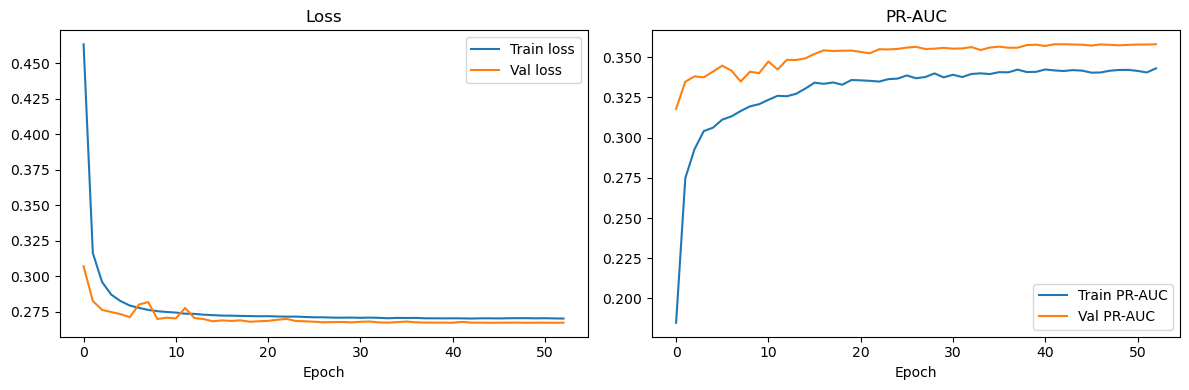

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_chuan.history["loss"], label="Train loss")
axes[0].plot(history_chuan.history["val_loss"], label="Val loss")
axes[0].set_xlabel("Epoch"); axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(history_chuan.history["pr_auc"], label="Train PR-AUC")
axes[1].plot(history_chuan.history["val_pr_auc"], label="Val PR-AUC")
axes[1].set_xlabel("Epoch"); axes[1].set_title("PR-AUC"); axes[1].legend()
plt.tight_layout()
plt.show()
# Val loss tang tro lai trong khi train loss tiep tuc giam la dau hieu overfit;
# EarlyStopping se tu dong dung va khoi phuc trong so tot nhat theo val_pr_auc


## 8. Thu 3 kien truc

In [9]:
kien_truc_list = [(64,), (128, 64), (256, 128, 64)]
ket_qua_kien_truc = []
for kt in kien_truc_list:
    m = tao_mlp_chuan(hidden_layer_sizes=kt, dropout_rates=[0.3] * len(kt))
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy",
              metrics=[tf.keras.metrics.AUC(curve="PR", name="pr_auc")])
    h = m.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50,
              batch_size=1024, callbacks=[callbacks[0]], verbose=0)
    pr_auc = average_precision_score(y_test, m.predict(X_test, verbose=0).ravel())
    ket_qua_kien_truc.append([str(kt), m.count_params(), pr_auc])

bang_kien_truc = pd.DataFrame(ket_qua_kien_truc, columns=["Kien_truc", "So_tham_so", "PR_AUC"])
print(bang_kien_truc)


        Kien_truc  So_tham_so    PR_AUC
0           (64,)        1025  0.343215
1       (128, 64)       10497  0.348549
2  (256, 128, 64)       45825  0.351664


## 9. So sanh class_weight

In [10]:
from sklearn.utils.class_weight import compute_class_weight

trong_so = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
class_weight = {0: trong_so[0], 1: trong_so[1]}

mlp_khong_cw = tao_mlp_chuan()
mlp_khong_cw.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy",
                      metrics=[tf.keras.metrics.AUC(curve="PR", name="pr_auc")])
mlp_khong_cw.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50,
                  batch_size=1024, callbacks=[callbacks[0]], verbose=0)
pr_auc_khong_cw = average_precision_score(y_test, mlp_khong_cw.predict(X_test, verbose=0).ravel())

mlp_co_cw = tao_mlp_chuan()
mlp_co_cw.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy",
                   metrics=[tf.keras.metrics.AUC(curve="PR", name="pr_auc")])
mlp_co_cw.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=1024,
              class_weight=class_weight, callbacks=[callbacks[0]], verbose=0)
pr_auc_co_cw = average_precision_score(y_test, mlp_co_cw.predict(X_test, verbose=0).ravel())

print(f"Khong class_weight: PR-AUC={pr_auc_khong_cw:.4f}")
print(f"Co class_weight:    PR-AUC={pr_auc_co_cw:.4f}")


Khong class_weight: PR-AUC=0.3463
Co class_weight:    PR-AUC=0.3470


## 10. Embedding cho Region_Code va Policy_Sales_Channel

In [12]:
cot_so_khac = [c for c in cot_khong_embedding if c not in ["Region_Code_id", "Policy_Sales_Channel_id"]]

input_khac = layers.Input(shape=(len(cot_so_khac),), name="dac_trung_khac")
input_vung = layers.Input(shape=(1,), name="region_code")
input_kenh = layers.Input(shape=(1,), name="policy_channel")

emb_vung = layers.Embedding(so_luong_vung, 8)(input_vung)
emb_vung = layers.Flatten()(emb_vung)
emb_kenh = layers.Embedding(so_luong_kenh, 8)(input_kenh)
emb_kenh = layers.Flatten()(emb_kenh)

noi = layers.Concatenate()([input_khac, emb_vung, emb_kenh])
x = layers.Dense(128, activation="relu")(noi)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
output = layers.Dense(1, activation="sigmoid")(x)

mlp_embedding = models.Model([input_khac, input_vung, input_kenh], output)
mlp_embedding.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy",
                       metrics=[tf.keras.metrics.AUC(curve="PR", name="pr_auc")])

def tach_dau_vao(X):
    return [
        X[cot_so_khac].astype(np.float32).values,
        X["Region_Code_id"].astype(np.int32).values,
        X["Policy_Sales_Channel_id"].astype(np.int32).values,
    ]

mlp_embedding.fit(tach_dau_vao(X_train), y_train,
                   validation_data=(tach_dau_vao(X_val), y_val),
                   epochs=50, batch_size=1024, callbacks=[callbacks[0]], verbose=0)
pr_auc_embedding = average_precision_score(y_test, mlp_embedding.predict(tach_dau_vao(X_test), verbose=0).ravel())

print(f"One-hot (khong embedding), so tham so~{mlp_chuan.count_params()}: PR-AUC={pr_auc_chuan:.4f}")
print(f"Embedding, so tham so={mlp_embedding.count_params()}: PR-AUC={pr_auc_embedding:.4f}")


One-hot (khong embedding), so tham so~10497: PR-AUC=0.3483
Embedding, so tham so=13953: PR-AUC=0.3683


## 11. Chon nguong theo Precision@3000

In [13]:
xac_suat_test = mlp_embedding.predict(tach_dau_vao(X_test), verbose=0).ravel()
thu_tu = np.argsort(-xac_suat_test)
top_3000 = thu_tu[:3000]
precision_tai_3000 = y_test.values[top_3000].mean()
print(f"Precision@3000 (MLP embedding): {precision_tai_3000:.4f}")

# Nguong xac suat tuong ung voi diem cat top 3000 khach
nguong_top_3000 = xac_suat_test[top_3000[-1]]
print(f"Nguong xac suat tuong ung: {nguong_top_3000:.4f}")


Precision@3000 (MLP embedding): 0.4130
Nguong xac suat tuong ung: 0.3596


## 12. Bang ket luan: MLP Keras vs LightGBM

In [14]:
bang_ket_luan = pd.DataFrame([
    ["LightGBM", pr_auc_lgbm, t_lgbm, "Thap - it sieu tham so can tinh chinh"],
    ["MLP Keras (embedding)", pr_auc_embedding, None, "Cao - nhieu kien truc/sieu tham so, can GPU de train nhanh"],
], columns=["Model", "PR_AUC", "Thoi_gian_train(s)", "Cong_suc_tinh_chinh"])
print(bang_ket_luan)

if pr_auc_lgbm >= pr_auc_embedding:
    print("\nKet luan: LightGBM bang hoac tot hon MLP tren du lieu bang nay,")
    print("dung voi ky vong ly thuyet - cay thuong thang mang no-ron tren du lieu dang bang.")
else:
    print("\nKet luan: MLP embedding nhinh hon LightGBM trong lan chay nay,")
    print("nhung can doi chieu lai cong suc tinh chinh va thoi gian truoc khi chon trien khai.")


                   Model    PR_AUC  Thoi_gian_train(s)  \
0               LightGBM  0.370894            5.116787   
1  MLP Keras (embedding)  0.368286                 NaN   

                                 Cong_suc_tinh_chinh  
0              Thap - it sieu tham so can tinh chinh  
1  Cao - nhieu kien truc/sieu tham so, can GPU de...  

Ket luan: LightGBM bang hoac tot hon MLP tren du lieu bang nay,
dung voi ky vong ly thuyet - cay thuong thang mang no-ron tren du lieu dang bang.


In [16]:
import os

os.makedirs("models", exist_ok=True)
os.makedirs("reports", exist_ok=True)

mlp_embedding.save("models/best.keras")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_chuan.history["loss"], label="Train loss")
axes[0].plot(history_chuan.history["val_loss"], label="Val loss")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(history_chuan.history["pr_auc"], label="Train PR-AUC")
axes[1].plot(history_chuan.history["val_pr_auc"], label="Val PR-AUC")
axes[1].set_title("PR-AUC"); axes[1].legend()
plt.savefig("reports/learning_curves.png", dpi=150, bbox_inches="tight"); plt.close()

plt.figure(figsize=(7, 4))
plt.bar(bang_kien_truc["Kien_truc"], bang_kien_truc["PR_AUC"])
plt.ylabel("PR-AUC")
plt.title("So sanh 3 kien truc")
plt.savefig("reports/kien_truc_comparison.png", dpi=150, bbox_inches="tight"); plt.close()

plt.figure(figsize=(6, 4))
plt.bar(["One-hot", "Embedding"], [pr_auc_chuan, pr_auc_embedding])
plt.ylabel("PR-AUC")
plt.title("Embedding vs One-hot")
plt.savefig("reports/embedding_vs_onehot.png", dpi=150, bbox_inches="tight"); plt.close()

from sklearn.metrics import precision_recall_curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test, xac_suat_test)
plt.figure(figsize=(6, 5))
plt.plot(recall_curve, precision_curve)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("PR curve (MLP embedding)")
plt.savefig("reports/pr_curve.png", dpi=150, bbox_inches="tight"); plt.close()

with open("requirements.txt", "w") as f:
    f.write("tensorflow\nlightgbm\nscikit-learn\npandas\nnumpy\nmatplotlib\n")

readme_content = f"""# TT-25 - MLP voi Keras: Cham diem khach hang tiem nang

## Huong dan chay
1. Cai thu vien: `pip install tensorflow lightgbm scikit-learn pandas numpy matplotlib`
2. Dat file `health_insurance.csv` cung thu muc voi notebook `notebooks/mlp_keras_insurance.ipynb`
3. Restart Kernel roi Run All de chay dung thu tu tu dau den cuoi (co GPU se nhanh hon dang ke)
4. Ket qua duoc luu vao models/ va reports/ khi chay den cell cuoi

## Cac buoc da thuc hien va nhan xet

1. EDA xac nhan Previously_Insured va Vehicle_Damage la 2 yeu to phan biet manh nhat ty le quan tam.
2. Tien xu ly: log1p Annual_Premium, one-hot bien it muc, giu Region_Code/Policy_Sales_Channel
   dang ma so ({so_luong_vung} va {so_luong_kenh} muc) de dung Embedding.
3. Chia train/val/test co stratify, ty le Response giu nguyen ~12.3% o ca 3 tap.
4. Baseline LightGBM: PR-AUC={pr_auc_lgbm:.4f}, thoi gian train={t_lgbm:.1f}s.
5. MLP co ban (khong Dropout/BatchNorm): PR-AUC={pr_auc_co_ban:.4f}.
6. MLP + Dropout/BatchNorm: PR-AUC={pr_auc_chuan:.4f}.
7. Learning curve (reports/learning_curves.png) dung de chan doan overfit/underfit qua EarlyStopping.
8. So sanh 3 kien truc (reports/kien_truc_comparison.png):
{bang_kien_truc.to_string(index=False)}
9. class_weight: khong dung PR-AUC={pr_auc_khong_cw:.4f}, co dung PR-AUC={pr_auc_co_cw:.4f}.
10. Embedding vs one-hot (reports/embedding_vs_onehot.png): one-hot PR-AUC={pr_auc_chuan:.4f}
    ({mlp_chuan.count_params()} tham so), embedding PR-AUC={pr_auc_embedding:.4f}
    ({mlp_embedding.count_params()} tham so).
11. Precision@3000 = {precision_tai_3000:.4f}, nguong xac suat tuong ung = {nguong_top_3000:.4f}.
12. Ket luan trung thuc:
{bang_ket_luan.to_string(index=False)}

## Han che
- Voi du lieu dang bang, MLP thuong khong vuot troi ro ret so voi LightGBM, dung ky vong ly thuyet cua README.
- Embedding chi phat huy loi the khi so muc cua bien phan loai du lon va co du du lieu de hoc bieu dien tot.
- Chua thu nghiem TabNet/FT-Transformer hay xep chong model - la huong mo rong tiep theo.
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

print("Da luu: models/best.keras, reports/*.png, requirements.txt, README.md")

Da luu: models/best.keras, reports/*.png, requirements.txt, README.md
